## Visualizing: Volcano and Heatmap

TODO explain this notebook

1. Load the differential expression results and processed expression data
2. Prepare the data for visualization
3. Generate a volcano plot to display significance and effect size across all genes
4. Identify the most strongly deregulated genes
5. Plot a heatmap of the top differentially expressed genes across samples
6. Interpret the main visual patterns observed

In [1]:
# imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Paths
project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent

# Get data path
data_path = str(project_root) + "/data"

# Get results path
result_path = str(project_root) + "/results"


# Step 1: Load data

TODO explain process quickly

In [4]:
results = pd.read_csv(result_path + "/tables/differential_expression_results.csv", index_col=0)
X = pd.read_csv(data_path + "/processed/X_clean.csv")
y = pd.read_csv(data_path + "/processed/y_clean.csv").squeeze()

# Step 2: Perpare data for plotting

TODO explain in detal (including choice of neg_log10_adj_p)

In [5]:
results = results.copy()

results["neg_log10_adj_p"] = -np.log10(results["adj_p_value"] + 1e-300)

results["significance"] = "Not significant"
results.loc[
    (results["adj_p_value"] < 0.05) & (results["log2FC"] > 1),
    "significance"
] = "Upregulated in tumor"

results.loc[
    (results["adj_p_value"] < 0.05) & (results["log2FC"] < -1),
    "significance"
] = "Downregulated in tumor"

results["gene"] = results.index
results.head()

,mean_tumor,mean_normal,log2FC,p_value,adj_p_value,neg_log10_adj_p,significance,gene
1007_s_at,10.392065,10.219646,0.172420,0.361709,0.445466,0.351185,Not significant,1007_s_at
1053_at,7.569988,6.428852,1.141136,0.000040,0.000491,3.309303,Upregulated in tumor,1053_at
117_at,6.363503,5.527662,0.835841,0.000663,0.003954,2.402919,Not significant,117_at
121_at,7.299507,7.587111,-0.287604,0.131963,0.198527,0.702180,Not significant,121_at
1255_g_at,3.172048,3.322261,-0.150213,0.053255,0.098941,1.004625,Not significant,1255_g_at


# Step 3: Volcano visualization

TODO explain why choice volcano, why 


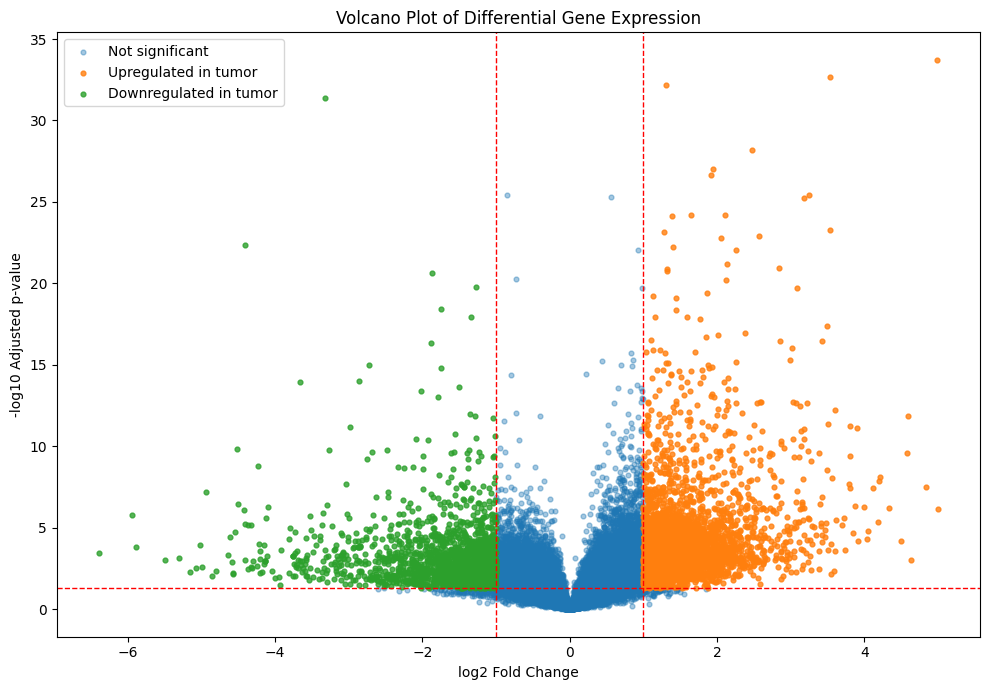

In [8]:
plt.figure(figsize=(10, 7))

for category, alpha in [
    ("Not significant", 0.4),
    ("Upregulated in tumor", 0.8),
    ("Downregulated in tumor", 0.8),
]:
    subset = results[results["significance"] == category]
    plt.scatter(
        subset["log2FC"],
        subset["neg_log10_adj_p"],
        label=category,
        alpha=alpha,
        s=12
    )

plt.axvline(x=1, linestyle="--", linewidth=1, color="red")
plt.axvline(x=-1, linestyle="--", linewidth=1, color="red")
plt.axhline(y=-np.log10(0.05), linestyle="--", linewidth=1, color="red")

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 Adjusted p-value")
plt.title("Volcano Plot of Differential Gene Expression")
plt.legend()
plt.tight_layout()
plt.show()